In [22]:
!pip install seaborn
!pip install  scikit-learn
!pip install gdown


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import gdown
import zipfile
import os

file_url = "https://drive.google.com/file/d/1jkoe1E5K7slFeP1Uwo2FBY2HLJPImYua/view?usp=sharing"

file_id = file_url.split("/d/")[1].split("/")[0]

output_zip = "downloaded_file.zip"  # Name for the downloaded zip
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

# Unzip the file
extract_dir = "generated_simple/"  # Directory to extract into
os.makedirs(extract_dir, exist_ok=True)  # Create directory if it doesn't exist

with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ File downloaded and extracted to: {extract_dir}")

Downloading...
From (original): https://drive.google.com/uc?id=1jkoe1E5K7slFeP1Uwo2FBY2HLJPImYua
From (redirected): https://drive.google.com/uc?id=1jkoe1E5K7slFeP1Uwo2FBY2HLJPImYua&confirm=t&uuid=6a391195-5881-4375-98d9-08f64aa3034b
To: /Users/Marichka/Studing/Uni/Project/Iran/PHLOP/downloaded_file.zip
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79.0M/79.0M [00:04<00:00, 17.6MB/s]


✅ File downloaded and extracted to: generated_simple/


In [11]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from sklearn.mixture import GaussianMixture
import matplotlib.patches as mpatches
from scipy import stats


In [12]:
def load_data(directory):
    data = []
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:

        if "obj.json" in filename:
            with open(filename, 'r') as file:
                data.append(json.load(file))
    return data

def extract_time_series(data):
    frames = data.get("frames", {})
    objects = data.get("objects", {})

    objects_dict = {obj["id"]: obj for obj in objects}


    object_ids = list(frames[0]["objects"].keys())
    time_series_data = {obj_id: {"velocity": [], "angular_velocity": [], "acceleration": [], 
                                 "collision": [],
                                 "friction": [], 
                                 # "mass": [],
                                } for obj_id in object_ids}

    prev_velocities = {obj_id: np.array([0, 0, 0]) for obj_id in object_ids}
    prev_time = frames[0]["time"]

    for frame in frames:
        current_time = frame["time"]
        dt = current_time - prev_time
        prev_time = current_time

        for obj_id in object_ids:
            obj_data = frame["objects"].get(obj_id, {})
    
            raw_f = objects_dict[obj_id].get("friction", "0 0 0").split()
            f_val = np.mean([float(x) for x in raw_f])
            time_series_data[obj_id]["friction"].append(f_val)
            # print("friction", friction)
            
            # time_series_data[obj_id]["friction"].append(np.mean(friction))
            # time_series_data[obj_id]["mass"].append(float(objects_dict.get(obj_id, '').get("mass", "0")))

            
            velocity = np.array(obj_data.get("velocity", [0, 0, 0]))
            angular_velocity = np.array(obj_data.get("angular_velocity", [0, 0, 0]))

            time_series_data[obj_id]["velocity"].append(np.linalg.norm(velocity))
            time_series_data[obj_id]["angular_velocity"].append(np.linalg.norm(angular_velocity))

            if dt > 0:
                acceleration = (velocity - prev_velocities[obj_id]) / dt
                time_series_data[obj_id]["acceleration"].append(np.linalg.norm(acceleration))
            else:
                time_series_data[obj_id]["acceleration"].append(0)

            prev_velocities[obj_id] = velocity

            collision_detected = 0
            taxonomy = obj_data.get("taxonomy", [])
            for event in taxonomy:
                if (event.get("category") == "Interaction Events" and 
                    event.get("subcategory") == "Collisions"):
                    collision_detected = 1
                    break
            time_series_data[obj_id]["collision"].append(max(collision_detected, 1e-6))

    return time_series_data

def compute_corr(x, y):
    x = np.array(x)
    y = np.array(y)
    if len(x) < 2 or len(y) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0,1]


def get_collision_count(data):
    object_ids = list(data[0]["objects"].keys())
    collision_counts = {obj_id: 0 for obj_id in object_ids}
    
    for frame in data:
        for obj_id in object_ids:
            taxonomy = frame["objects"].get(obj_id, {}).get("taxonomy", [])
            for event in taxonomy:
                if event.get("category") == "Interaction Events" and event.get("subcategory") == "Collisions":
                    collision_counts[obj_id] += 1
    return collision_counts

def comput_self_correlation(df, features):
    """
    Takes a time series data  and computes for each object a correlation matrix of its features
    then avg them per object
    """
    self_corrs = []
    object_ids = list(df.keys())
    
    for obj in object_ids:
        # object features
        data = {feat: ts_data[obj].get(feat, []) for feat in features}
        df = pd.DataFrame(data)
        # corr matrix
        corr_matrix = df.corr(method='pearson')
        self_corrs.append(corr_matrix.values)
    # print('self_corrs', self_corrs)
    if self_corrs:
        self_avg = np.nanmean(np.array(self_corrs), axis=0)
    else:
        self_avg = np.full((len(features), len(features)), np.nan)
    # avg
    self_corr_df = pd.DataFrame(self_avg, index=features, columns=features)

    return self_corr_df

def comput_cross_correlation(df, features):
    """
    Takes a time series data  and computes for each object a correlation matrix of other object's features
    then avg them per object
    """
    cross_corrs = []
    object_ids = list(ts_data.keys())
    n_objects = len(object_ids)
    
    for i in range(n_objects):
        for j in range(i+1, n_objects):
            matrix_ij = np.empty((len(features), len(features)))
            for a, feat_a in enumerate(features):
                for b, feat_b in enumerate(features):
                    x = ts_data[object_ids[i]].get(feat_a, [])
                    y = ts_data[object_ids[j]].get(feat_b, [])
                    matrix_ij[a, b] = compute_corr(x, y)
            cross_corrs.append(matrix_ij)
    
    if cross_corrs:
        cross_avg = np.nanmean(np.array(cross_corrs), axis=0)
    else:
        cross_avg = np.full((len(features), len(features)), np.nan)
    
    cross_corr_df = pd.DataFrame(cross_avg, index=features, columns=features)
    return cross_corr_df
    
def compute_self_and_cross_correlations(ts_data):
    features = ["velocity", "angular_velocity", "acceleration", "collision", "friction"]
                # , "friction", "mass"]


    self_corr_df = comput_self_correlation(ts_data, features)
    cross_corr_df = comput_cross_correlation(ts_data, features)

    return self_corr_df, cross_corr_df

def plot_correlation_distributions(matrices, features, video_ids=[]):
    colors = ["blue", "green", "purple", "orange", "brown", "pink", "red", "yellow"]
    matrix_stack = np.array([df.values for df in matrices])

    plt.figure(figsize=(15, 10))

    if not video_ids:
        video_ids = [f"Video {i+1}" for i in range(len(matrices))]
    
    for i, feat1 in enumerate(features):
        for j, feat2 in enumerate(features):
            plt.subplot(len(features), len(features), i*len(features)+j+1)

            values = matrix_stack[:, i, j]
            valid_values = values[~np.isnan(values)]
            
            # a df to store values with video IDs
            value_df = pd.DataFrame({
                'value': values,
                'video_id': video_ids
            }).dropna()

            mean, std = 0, 0
            if len(valid_values) > 0:
                mean = np.mean(valid_values)
                std = np.std(valid_values)
                
                # Get top videos with highest mean values
                top_videos = value_df.nlargest(3, 'value')['video_id'].tolist()
                stats_text = f"mean={mean:.2f}\nstd={std:.2f}\nTop: {', '.join(top_videos)}"
                
                color = np.random.choice(colors)
                
                sns.histplot(valid_values, bins=30, kde=True, color=color)
                plt.title(f"{feat1} vs {feat2}\n{stats_text}")
                plt.xlim(-1, 1)
                plt.ylabel("Density")
                plt.xlabel("Correlation")
            else:
                plt.title(f"{feat1} vs {feat2}\nNo valid data")
        
    plt.tight_layout()
    plt.show()

def plot_MG_correlation_distributions(matrices, features, video_ids=[]):
    colors = ["blue", "green", "purple", "orange", "brown", "pink", "red", "yellow"]
    matrix_stack = np.array([df.values for df in matrices])

    plt.figure(figsize=(15, 10))

    if not video_ids:
        video_ids = [f"Video {i+1}" for i in range(len(matrices))]
    
    for i, feat1 in enumerate(features):
        for j, feat2 in enumerate(features):
            plt.subplot(len(features), len(features), i*len(features)+j+1)

            values = matrix_stack[:, i, j]
            valid_values = values[~np.isnan(values)]
            
            # Create a DataFrame to store values with video IDs
            value_df = pd.DataFrame({
                'value': values,
                'video_id': video_ids
            }).dropna()

            mean, std = 0, 0
            if len(valid_values) > 0:
                # find the Gaussian Mixture 
                # transform data
                # print(valid_values.shape)
                # break
                X = valid_values.reshape(-1, 1)
                optimal_n = 2
                gmm = GaussianMixture(n_components=optimal_n, covariance_type='full')
                gmm.fit(X)
                means = gmm.means_.flatten()
                stds = np.sqrt(gmm.covariances_).flatten()
                weights = gmm.weights_.flatten()
                # mean = np.mean(valid_values)
                # std = np.std(valid_values)
                
                # get top videos with highest mean values
                # top_videos = value_df.nlargest(3, 'value')['video_id'].tolist()
                # stats_text = f"mean={round(mean, 2)}\nstd={round(std, 2)}\nTop: {'\n'.join(top_videos)}"
                
                component_info = []
                for k in range(optimal_n):
                    # find  videos with values closest to distribiution mean
                    value_df['distance'] = np.abs(value_df['value'] - means[k])
                    closest_videos = value_df.nsmallest(3, 'distance')['video_id'].tolist()
                    component_info.append(f"Comp {k+1}: {', '.join(closest_videos)}")
                
                stats_text = (f"Components: {optimal_n}\n"
                            f"Means: {', '.join([f'{round(m,2)}' for m in means])}\n"
                            f"Top videos:\n" + '\n'.join(component_info))
                
                
                color = np.random.choice(colors)
                
                sns.histplot(valid_values, bins=30, kde=True, color=color)
                plt.title(f"{feat1} vs {feat2}\n{stats_text}")
                plt.xlim(-1, 1)
                plt.ylabel("Density")
                plt.xlabel("Correlation")
            else:
                plt.title(f"{feat1} vs {feat2}\nNo valid data")
        
    plt.tight_layout()
    plt.show()



In [17]:
directory = 'generated_simple'
data = load_data(directory)

In [18]:
all_video_self = []
all_video_cross = []

for video_data in data:
    # self_corr, cross_corr = process_video_data(video_data)
    ts_data = extract_time_series(video_data)
    # print("ts_data", ts_data)
    self_corr, cross_corr = compute_self_and_cross_correlations(ts_data)
    all_video_self.append(self_corr)
    all_video_cross.append(cross_corr)
    # break


/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_78878/2717003821.py:107: RuntimeWarning: Mean of empty slice
  self_avg = np.nanmean(np.array(self_corrs), axis=0)
/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_78878/2717003821.py:135: RuntimeWarning: Mean of empty slice
  cross_avg = np.nanmean(np.array(cross_corrs), axis=0)


/Users/Marichka/Studing/Uni/Project/Iran/PHLOP/.venv/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/Marichka/Studing/Uni/Project/Iran/PHLOP/.venv/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/Marichka/Studing/Uni/Project/Iran/PHLOP/.venv/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/Marichka/Studing/Uni/Project/Iran/PHLOP/.venv/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smal

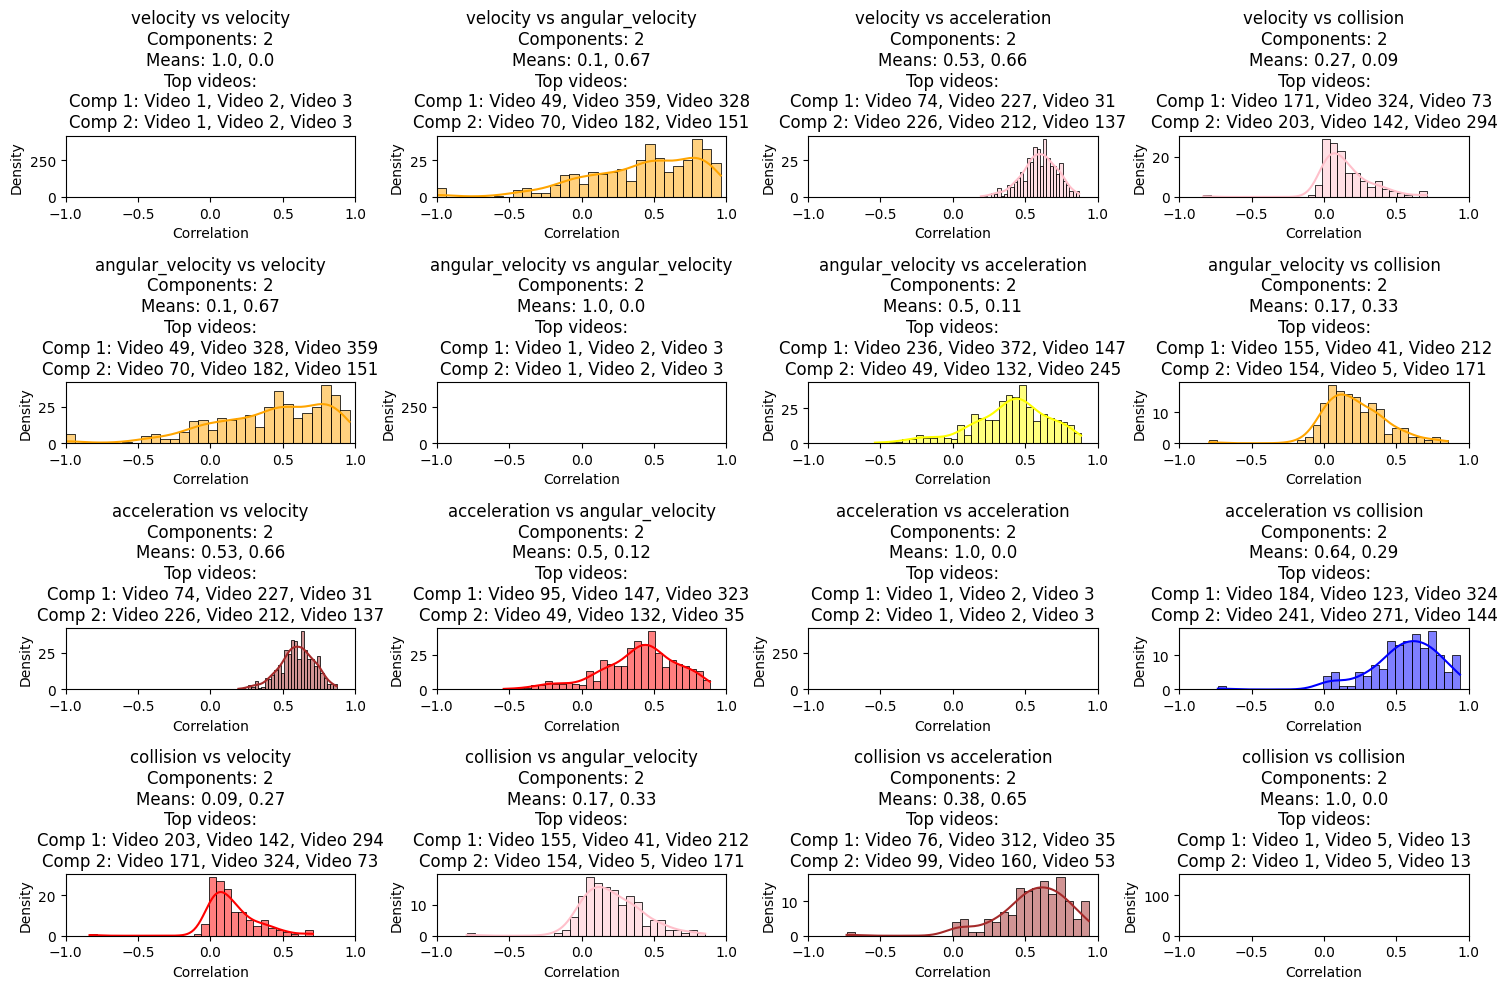

In [19]:
features = ["velocity", "angular_velocity", "acceleration", "collision"]
            # , "friction"]
# plot_correlation_distributions(all_video_self, features)
plot_MG_correlation_distributions(all_video_self, features)

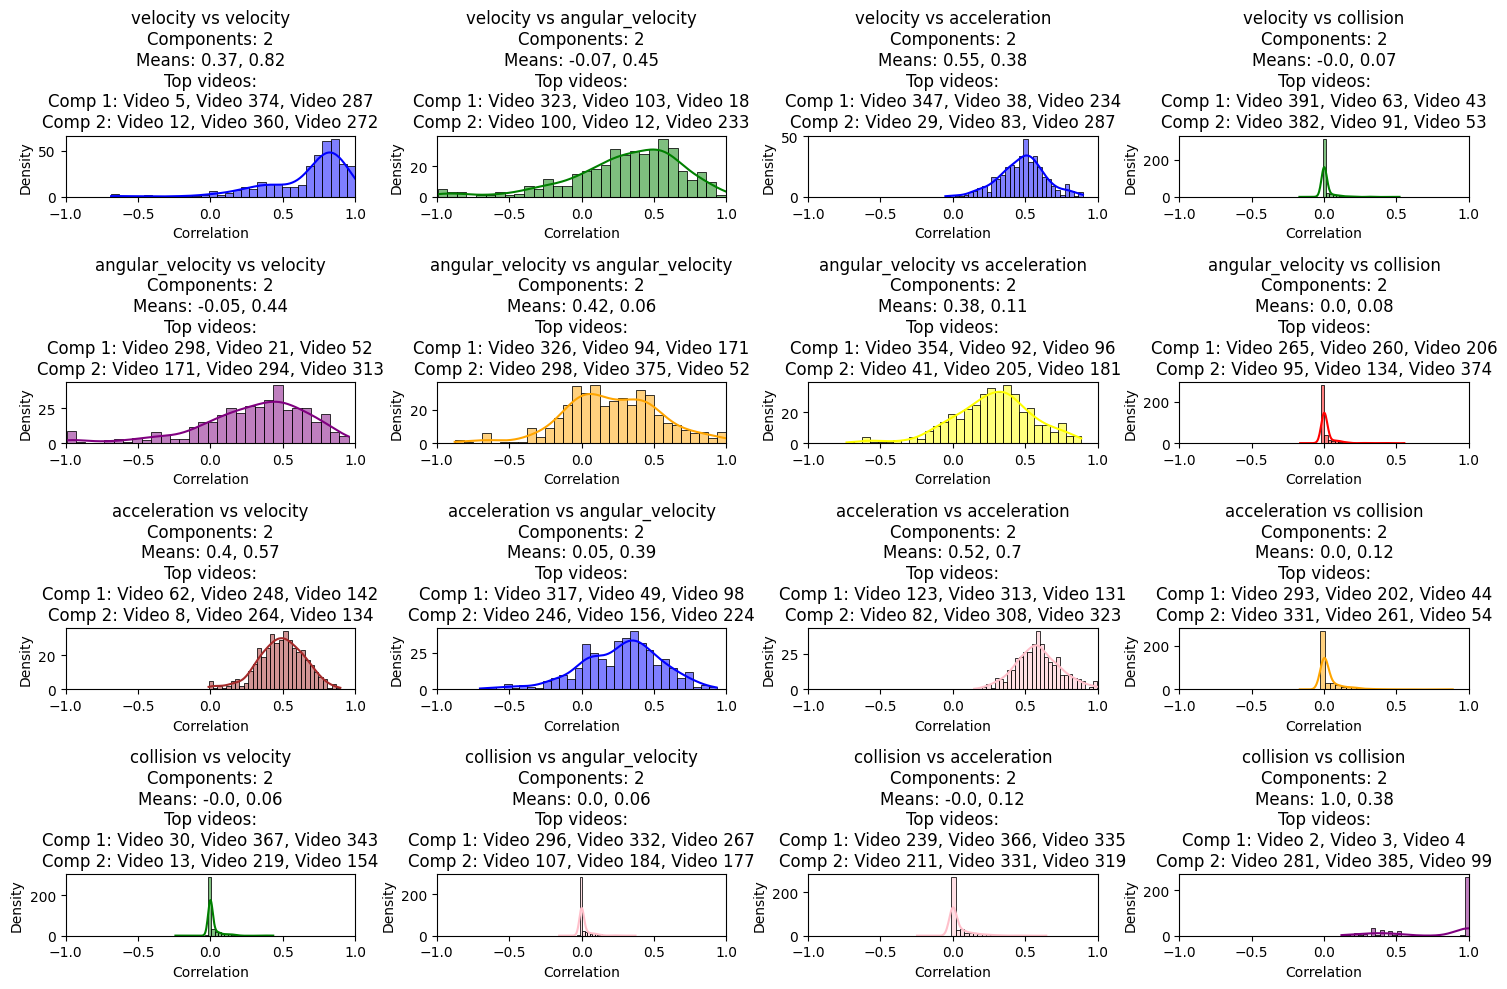

In [20]:
features = ["velocity", "angular_velocity", "acceleration", "collision"]
            # , "friction"]
# plot_correlation_distributions(all_video_cross, features)
plot_MG_correlation_distributions(all_video_cross, features)

## Plot mean of the correlation matrices

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_78878/152576259.py:1: RuntimeWarning: Mean of empty slice
  final_avg_self = np.nanmean(np.array(all_video_self), axis=0)


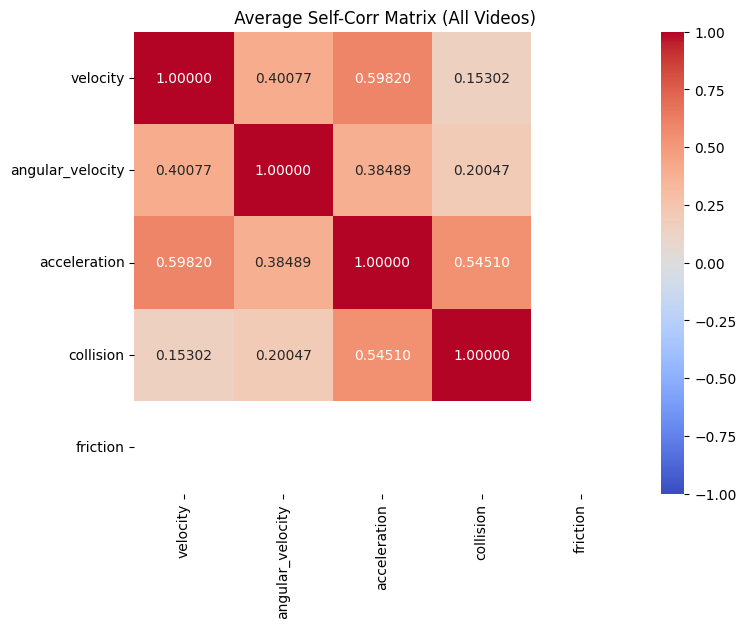

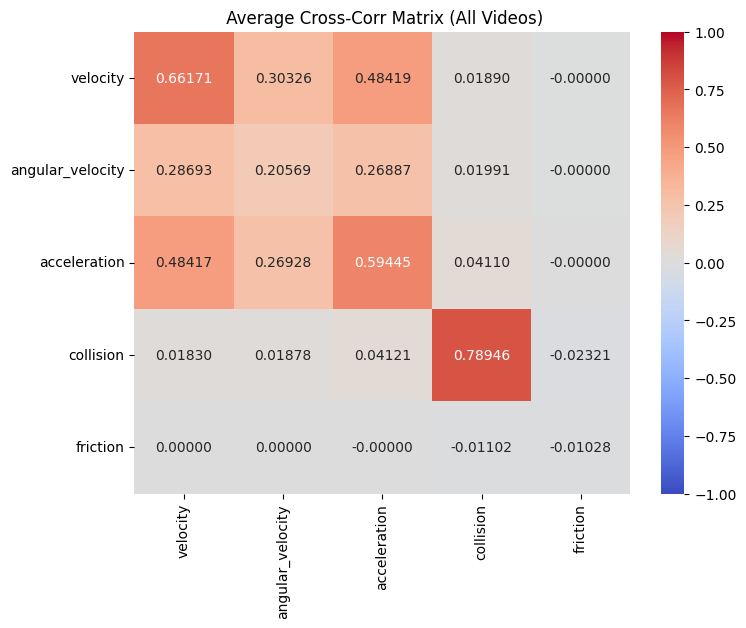

In [16]:

final_avg_self = np.nanmean(np.array(all_video_self), axis=0)
final_avg_cross = np.nanmean(np.array(all_video_cross), axis=0)

features = ["velocity", "angular_velocity", "acceleration", "collision", "friction"]
final_avg_self_df = pd.DataFrame(final_avg_self, index=features, columns=features)
final_avg_cross_df = pd.DataFrame(final_avg_cross, index=features, columns=features)



plt.figure(figsize=(8, 6))
sns.heatmap(final_avg_self_df, annot=True,  cmap='coolwarm', fmt=".5f",  vmin=-1, vmax=1)
plt.title(" Average Self-Corr Matrix (All Videos)")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(final_avg_cross_df, annot=True,  cmap='coolwarm', fmt=".5f", vmin=-1, vmax=1)
plt.title(" Average Cross-Corr Matrix (All Videos)")
plt.show()

